In [3]:
import numpy as np

np.array([10,20,30,40,50]).mean()
np.array([10,20,30,40,50])*2
arr = np.array([1000,20,3000,40,50])
(arr >= 1000).sum()
np.argsort(-arr)[:3]
(arr[ arr < 1000] * 50).sum()
newarr = np.where(arr<40, arr*1.2, np.where( arr<1000, arr *1.1, arr))
newarr



array([1000.,   24., 3000.,   44.,   55.])

In [4]:
import pandas as pd
import datetime
df= pd.read_csv("../datasets/ecommerce/orders_raw.csv")
df.columns
df.shape
df.dtypes
type(df)
# df.info()
#df.describe()
df.columns = df.columns.str.strip().str.lower()
print(df.columns.tolist())
df['amount'] = df['amount'].str.strip('$').str.replace(',','').astype(float)
#df['amount']
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
# df.info()

df = df.dropna(subset=['order_date', 'amount'])
# df.info()
df['qty'] = df['qty'].fillna(df['qty'].median)
df.info()    
df = df.drop_duplicates()
df.info()


['order_id', 'customer_id', 'product_id', 'qty', 'order_date', 'amount']
<class 'pandas.DataFrame'>
Index: 198 entries, 0 to 209
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     198 non-null    int64         
 1   customer_id  198 non-null    int64         
 2   product_id   198 non-null    int64         
 3   qty          198 non-null    object        
 4   order_date   198 non-null    datetime64[us]
 5   amount       198 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(3), object(1)
memory usage: 10.8+ KB
<class 'pandas.DataFrame'>
Index: 188 entries, 0 to 208
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     188 non-null    int64         
 1   customer_id  188 non-null    int64         
 2   product_id   188 non-null    int64         
 3   qty          188 non-null  

In [19]:
order = pd.read_csv("../datasets/ecommerce/orders_clean.csv")
customer = pd.read_csv("../datasets/ecommerce/customers.csv")
prod = pd.read_csv("../datasets/ecommerce/products.csv")
#print(order.columns)
#print(customer.columns)
#print(prod.columns)

df = ( 
    order.merge(customer, how='left', on='customer_id')
    .merge(prod, how='left', on='product_id')
)
# print(df.columns)
mask = (df['vip_level'] == 'Gold')
df[mask]['amount'].sum()

print(mask.sum(), df[mask]['amount'].sum())
region = df.groupby('region')['amount'].mean()
region.name = '平均金額'
region
df
# df.groupby('category')['amount'].sum()
# df.groupby('category')['amount'].sum().idxmax()

79 285982.0


,order_id,customer_id,product_id,qty,order_date,amount,customer_name,region,signup_date,vip_level,product_name,category,unit_price,stock_qty
0,5064,2022,1026,4.0,2025-03-26,8600.0,Victor Lin,North,2023-02-27,Gold,Dumbbell 5kg,Sports,2150,51
1,5023,2026,1021,5.0,2025-01-05,1355.0,Zoe Huang,South,2023-05-16,Platinum,Throw Pillow,Home,271,150
2,5123,2013,1013,2.0,2025-09-11,3538.0,Mia Huang,North,2023-07-17,Platinum,Cotton T-Shirt,Clothing,1769,174
3,5118,2005,1028,1.0,2025-05-22,1618.0,Emma Liu,West,2023-05-18,Bronze,Water Bottle,Sports,1618,186
4,5161,2017,1019,3.0,2025-08-20,1846.0,Quinn Chen,East,2023-08-11,Silver,Coffee Mug,Home,1846,274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,5094,2026,1019,3.0,2025-02-13,5538.0,Zoe Huang,South,2023-05-16,Platinum,Coffee Mug,Home,1846,274
184,5041,2014,1001,5.0,2025-10-03,8135.0,Nick Huang,West,2023-09-28,Gold,Wireless Mouse,Electronics,1627,12
185,5157,2005,1026,5.0,2025-01-02,10750.0,Emma Liu,West,2023-05-18,Bronze,Dumbbell 5kg,Sports,2150,51
186,5134,2015,1012,5.0,2025-06-03,9580.0,Olivia Huang,North,2023-12-15,Bronze,Clean Code,Books,1916,81


In [31]:
rfm = df.groupby('customer_id').agg(R=('order_date','max'),
                              F=('order_id','count'),
                              M=('amount','sum')).reset_index().sort_values('M', ascending=False)
rfm5 = rfm.head(5)
rfm5
rfm2 = rfm5.merge(df[['customer_name','customer_id']], how='left', on='customer_id').drop_duplicates()
rfm2


,customer_id,R,F,M,customer_name
0,2015,2025-12-23,12,56165.0,Olivia Huang
12,2022,2025-11-27,13,51242.0,Victor Lin
25,2025,2025-11-27,12,46739.0,Yuki Chen
37,2018,2025-12-26,12,43486.0,Rachel Lin
49,2021,2025-12-31,9,40346.0,Uma Wang


In [3]:
gdf = pd.read_csv("../datasets/ecommerce/orders_enriched.csv",
                     parse_dates=["order_date"])
gdf['月份'] = gdf['order_date'].dt.month
month_avg = gdf.groupby('月份')['amount'].mean()
month_avg.name = '平均金額'
month_avg

date_ord = gdf['order_date'].value_counts()
date_ord = date_ord.rename_axis('日期')
date_ord.name='訂單數'
date_ord

dmax = gdf['order_date'].max()
dmin = gdf['order_date'].min()
dmax, dmin

(Timestamp('2025-12-31 00:00:00'), Timestamp('2025-01-02 00:00:00'))

In [25]:
ts = gdf.set_index('order_date').sort_index()
monthly_revenue = ts['amount'].resample('ME').sum()
type(monthly_revenue)

mrr = monthly_revenue.rolling(window=3).mean()
mrr

cat_med = gdf.groupby('category')['amount'].median().sort_values(ascending=False)

gdf

,order_id,customer_id,product_id,qty,order_date,amount,customer_name,region,signup_date,vip_level,product_name,category,unit_price,stock_qty,月份
0,5064,2022,1026,4.0,2025-03-26,8600.0,Victor Lin,North,2023-02-27,Gold,Dumbbell 5kg,Sports,2150,51,3
1,5023,2026,1021,5.0,2025-01-05,1355.0,Zoe Huang,South,2023-05-16,Platinum,Throw Pillow,Home,271,150,1
2,5123,2013,1013,2.0,2025-09-11,3538.0,Mia Huang,North,2023-07-17,Platinum,Cotton T-Shirt,Clothing,1769,174,9
3,5118,2005,1028,1.0,2025-05-22,1618.0,Emma Liu,West,2023-05-18,Bronze,Water Bottle,Sports,1618,186,5
4,5161,2017,1019,3.0,2025-08-20,1846.0,Quinn Chen,East,2023-08-11,Silver,Coffee Mug,Home,1846,274,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,5094,2026,1019,3.0,2025-02-13,5538.0,Zoe Huang,South,2023-05-16,Platinum,Coffee Mug,Home,1846,274,2
184,5041,2014,1001,5.0,2025-10-03,8135.0,Nick Huang,West,2023-09-28,Gold,Wireless Mouse,Electronics,1627,12,10
185,5157,2005,1026,5.0,2025-01-02,10750.0,Emma Liu,West,2023-05-18,Bronze,Dumbbell 5kg,Sports,2150,51,1
186,5134,2015,1012,5.0,2025-06-03,9580.0,Olivia Huang,North,2023-12-15,Bronze,Clean Code,Books,1916,81,6


In [37]:
ts = gdf.set_index('order_date').sort_index()
mo = ts.resample('ME').agg(
        oc=('order_id','count'),
        cust=('customer_id','nunique'),
        rev=('amount','sum'),
        avg=('amount','mean')
    )
mo['pct'] = mo['rev'].pct_change()
mo



,oc,cust,rev,avg,pct
order_date,,,,,
2025-01-31,17,12,60062.0,3533.058824,NaN
2025-02-28,16,11,72367.0,4522.937500,0.204872
2025-03-31,17,11,55920.0,3289.411765,-0.227272
2025-04-30,14,11,58506.0,4179.000000,0.046245
2025-05-31,16,14,47879.0,2992.437500,-0.181639
2025-06-30,16,13,50901.0,3181.312500,0.063117
2025-07-31,11,9,40796.0,3708.727273,-0.198523
2025-08-31,24,16,62706.0,2612.750000,0.537062
2025-09-30,10,8,50745.0,5074.500000,-0.190747


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # 設定為微軟正黑體
plt.rcParams['axes.unicode_minus'] = False              # 解決負號顯示為方塊的問題
sns.set_theme(style='whitegrid')
import matplotlib.font_manager as fm
# 列出所有可用的字體名稱
# [f.name for f in fm.fontManager.ttflist if 'Chinese' in f.name or 'MS' in f.name]
# [f.name for f in fm.fontManager.ttflist if 'Jheng' in f.name or 'MS' in f.name]


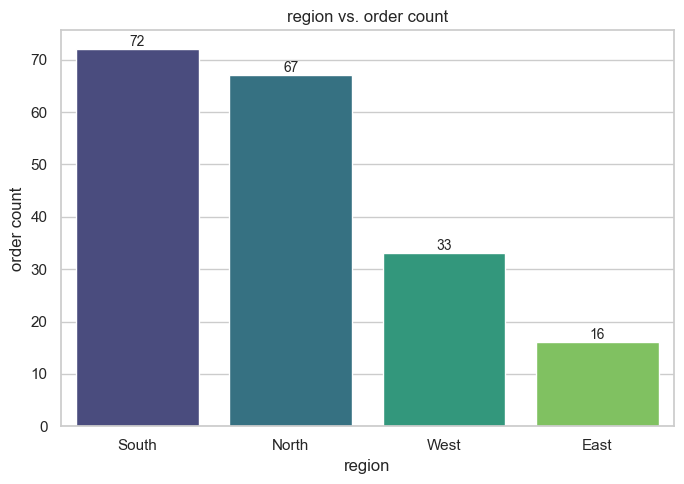

In [3]:
gdf = pd.read_csv("../datasets/ecommerce/orders_enriched.csv",
                     parse_dates=["order_date"])
# co = gdf['category'].value_counts()
# ax = co.plot(kind='bar',figsize=(10,4),title='Order count in Category',rot=45)
#  後續用ax 調整, 這個就是matplotlib 物件
#  plt.show() 是plt module 裡的一個函數,非class or instance level 
#  plt.show() 是總管：它會掃描目前程式中所有已經畫好的畫布，然後把它們一起打包裝進一個視窗裡顯示出來

# plt.figure(figsize=(10,4))
# sns.histplot(gdf['amount'], bins=20, stat='percent', kde=True)

reg_order = gdf['region'].value_counts().reset_index()
reg_order
plt.figure(figsize=(7,5))
sns.barplot(data=reg_order, x='region', y='count', palette='viridis', hue='region')
plt.xlabel('region')
plt.ylabel('order count')
plt.title('region vs. order count')
for r,c in enumerate(reg_order['count']):
    plt.text(r,c, f'{c:,.0f}', ha='center',va='bottom',fontsize=10)
plt.tight_layout()


C:\Users\f5486\AppData\Local\Temp\ipykernel_19080\167007142.py:8: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=piv.T, legend=True, markers='o')


Text(0.5, 1.0, 'North vs. South')

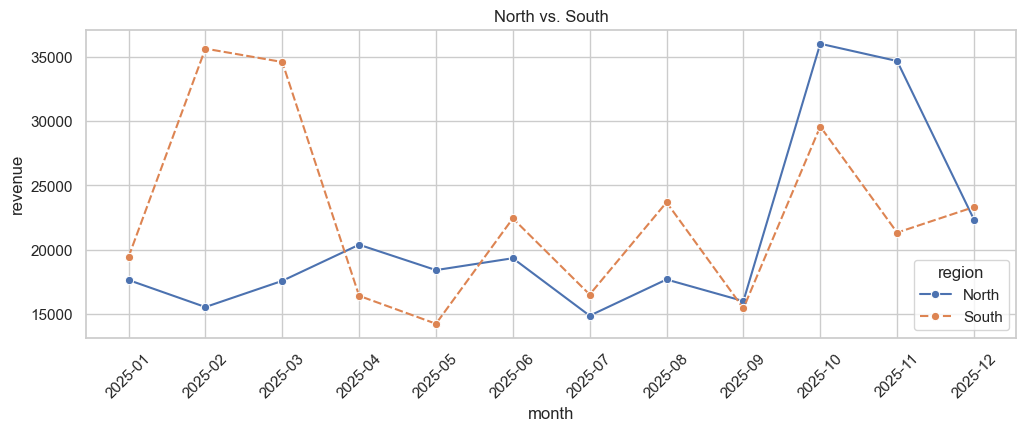

In [ ]:
#ts = gdf.set_index('order_date').sort_index()
#ts = ts[ ts['region'].isin(['North','South'])]
fig = plt.figure(figsize=(12,4))
filt = gdf[ gdf['region'].isin(['North','South'])]
filt['month']= filt['order_date'].dt.to_period('M').astype(str)
piv = filt.pivot_table(index='region', columns='month', values='amount', aggfunc='sum')
piv.T
sns.lineplot(data=piv.T, legend=True, markers='o')
plt.xticks(rotation=45)
plt.ylabel('revenue')
plt.title('North vs. South')

# sns.lineplot(data=filt,x='month',y='amount',hue='region')

<Axes: xlabel='unit_price', ylabel='amount'>

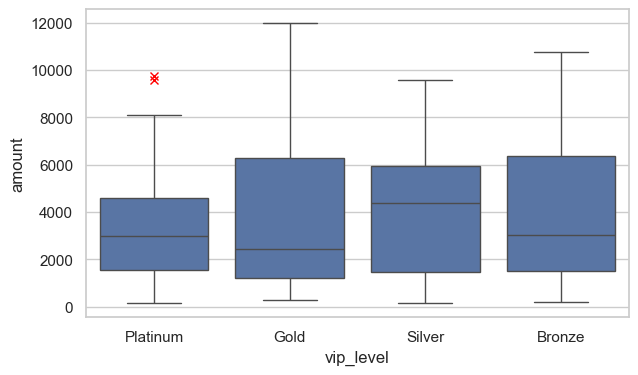

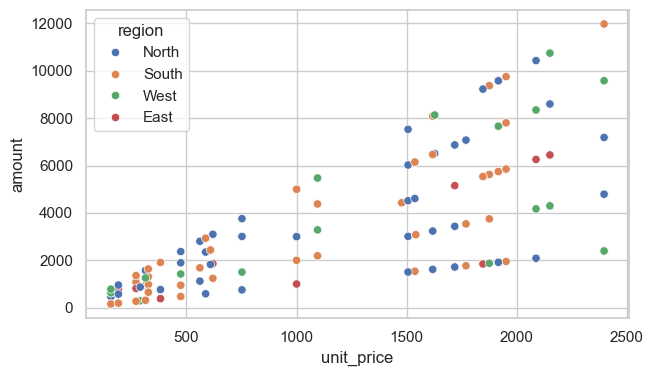

In [20]:
fig = plt.figure(figsize=(7,4))
my_order = ['Platinum', 'Gold', 'Silver', 'Bronze']
sns.boxplot(data=gdf, x='vip_level',y='amount', order=my_order, flierprops={'marker': 'x', 'markeredgecolor': 'red'}) #
#.xticks(['Platinum', 'Gold', 'Silver', 'Bronze'])
#紅色是離群值

fig = plt.figure(figsize=(7,4))
sns.scatterplot(data=gdf, x='unit_price', y='amount', hue='region')


C:\Users\f5486\AppData\Local\Temp\ipykernel_19080\94827295.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend(


Text(0, 0.5, 'Percent(%)')

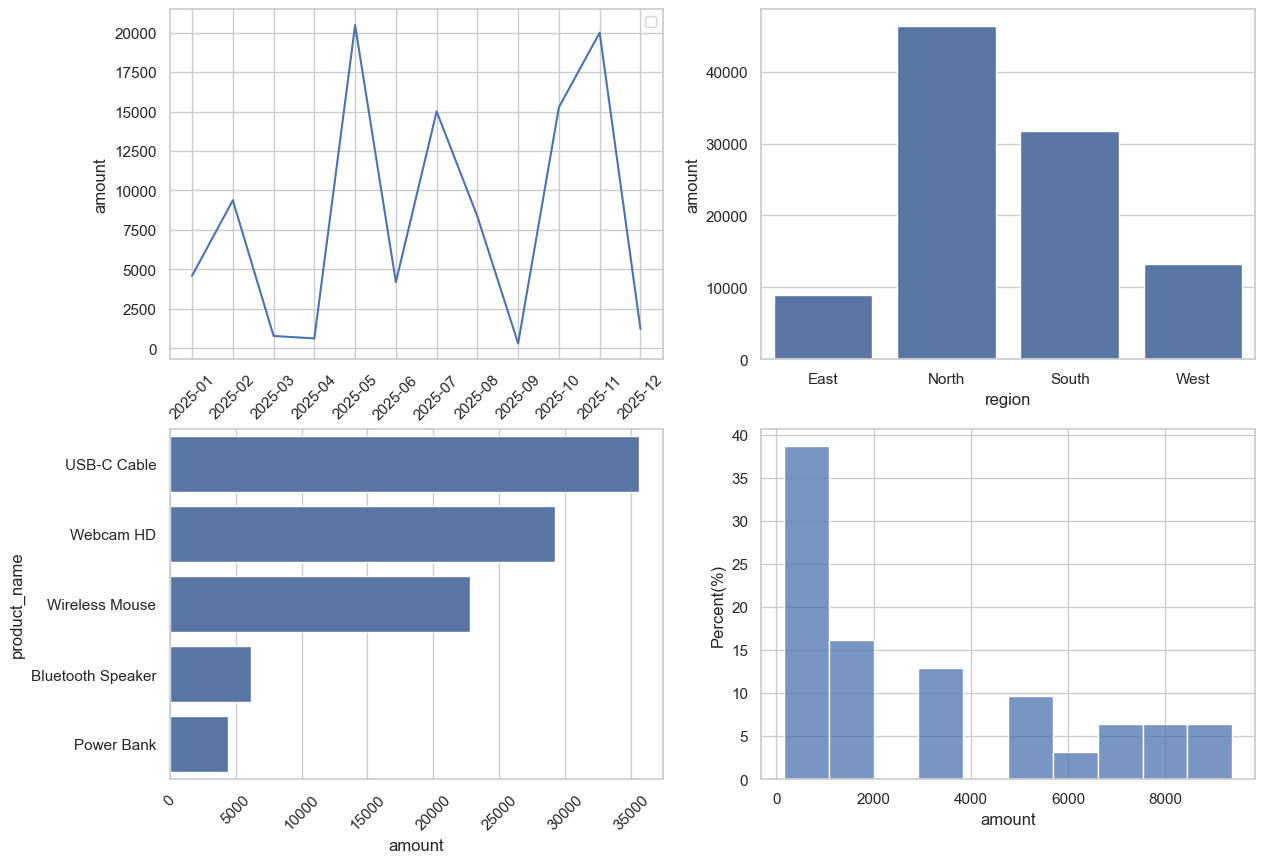

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
category="Electronics"
filt = gdf[ gdf['category'] == category]
filt['month'] = filt['order_date'].dt.to_period('M')
m_a = filt.groupby('month')['amount'].agg('sum').reset_index()
m_a['month'] = m_a['month'].astype(str)
sns.lineplot(data=m_a, x='month', y='amount',ax=axes[0,0])
axes[0,0].tick_params(axis='x', labelrotation=45)
axes[0,0].legend(
    loc='upper right',       # 放在右上角
    fontsize='small'
)

# gdf['month'] = gdf['order_date'].dt.to_period('M')
# c_m_r = gdf.groupby(['category','month'])['amount'].agg('sum').reset_index()
# c_m_r['month'] = c_m_r['month'].astype(str)
# sns.lineplot(data=c_m_r, x='month', y='amount', hue='category',ax=axes[0,0])
# axes[0,0].tick_params(axis='x', labelrotation=45)
# axes[0,0].legend(
#     loc='upper right',       # 放在右上角
#     fontsize='small'
# )
# #plt.xticks(rotation=45,)


r_a = filt.groupby('region')['amount'].agg('sum').reset_index()
sns.barplot(data=r_a, x='region', y='amount', ax=axes[0,1])

p_a = filt.groupby('product_name')['amount'].agg('sum').sort_values(ascending=False).head(5).reset_index()
# p_a['product_name'] = p_a['product_name'].replace("Data Science Handbook", "Data Science\nHandbook")
sns.barplot(data=p_a, x='amount', y='product_name', ax=axes[1,0],orient='h')
axes[1,0].tick_params(axis='x', labelrotation=45)

filt.head(5)
sns.histplot(filt['amount'], bins=10, stat='percent',ax=axes[1,1])
axes[1,1].set_ylabel('Percent(%)')

# axes[1,0].tick_params(axis='y', labelrotation=45)

In [89]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.templates.default = 'plotly_white'  # 乾淨白底

In [99]:
df = pd.read_csv("../datasets/ecommerce/orders_enriched.csv",
                    parse_dates=["order_date"])
# c_a = df.groupby('category', as_index=False)['amount'].sum()
# fig = px.bar(c_a, x='category',y='amount',text='amount', color='category', title='category vs. amount')
# fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
# fig.update_layout(height=500, showlegend=False)
#fig.show()

# ts = df.set_index('order_date').sort_index()
# m_a = ts['amount'].resample('ME').sum()
# m_a = m_a.reset_index()
# fig = px.line(m_a, 'order_date', 'amount', markers=True, title='month vs. amount')
# fig.show()


# fig = px.pie(df, 'vip_level')
fig = px.scatter(df, 'unit_price', 'amount', hover_data=['product_name'], color='category', title='unit price vs. amount')

fig.show()

In [ ]:
df['month'] = df['order_date'].dt.to_period('M').astype(str)
m_a = df.groupby('month', as_index=False)['amount'].sum()
p_a = df.groupby('product_name', as_index=False)['amount'].sum().sort_values('amount',ascending=False).head(10)
r_a = df.groupby('region', as_index=False)['amount'].sum()
c_a = df.groupby('category', as_index=False)['amount'].sum()

fig = make_subplots(2,2, subplot_titles= ('Monthly revenue trend', 'Top 10 Products', 'Revenue by region', 'Category share'), 
                   specs=[ [{'type':'xy'}, {'type':'xy'}], [{'type':'xy'}, {'type':'domain'}] ])
    
fig.add_trace(go.Scatter(x=m_a['month'], y=m_a['amount'],mode='line+marker', name='Monthly' ), row=1, col=1)
fig.add_trace(go.Bar(x=p_a['product_name'], y=p_a['amount']), row=1, col=2)
fig.add_trace(go.Bar(x=r_a['region'], y=r_a['amount']), row=2, col=1)
fig.add_trace(go.Pie(x=c_a['category'], y=c_a['amount']), row=2, col=2)

,category,amount
0,Books,182244.0
1,Clothing,133841.0
2,Electronics,100235.0
3,Home,93753.0
4,Sports,176315.0
